# 03 Content Style Clustering

Goal: group posts by **how captions are written** and profile each style cluster.


In [35]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from collections import Counter
from IPython.display import display
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 200)


## Load Data


In [36]:
try:
    df = pd.read_json(r"C:\Users\hanib\data-mining-project\marketing\data\processed\kpi_dataset.json")
except ValueError:
    df = pd.read_json(r"C:\Users\hanib\data-mining-project\marketing\data\processed\kpi_dataset.json", lines=True)
print(df.shape)
display(df.head(3))


(775, 42)


,business_name,sector,followers_count,post_date,day_of_week,month,post_type,caption_text,caption_length,hashtags_count,...,is_reel,posting_time_bin,caption_length_bin,hashtags_count_bin,emoji_count_bin,engagement_level,business_size_bin,high_engagement,high_view_rate,high_comment_rate
0,LOFT Palestine,Fashion,4392,1774915,Tuesday,1,reel,إطلالة أنثوية بلمسة عصرية ✨ من LOFT. للطلب التواصل على الرسائل 📩 رام الله - ايكون مول - ط2,88,0,...,1,night,medium,none,few,medium,small,0,0,0
1,LOFT Palestine,Fashion,4392,1773792,Wednesday,1,reel,اختيارك المثالي لإطلالة كاجول مميزة 🤍✨ LOFT كولكشن للطلب التواصل على الرسائل 📩 رام الله - ايكون مول - ط2,111,0,...,1,night,medium,none,few,high,small,1,1,0
2,LOFT Palestine,Fashion,4392,1773619,Monday,1,reel,ستايل شبابي بلمسة عصرية له ولها ✨ اختيارات مميزة وإطلالات كاملة من LOFT. للطلب التواصل على الرسائل 📩 رام الله - ايكون مول - ط2,133,0,...,1,night,medium,none,few,high,small,1,1,1


## Simple EDA


In [37]:
print('Columns:')
print(df.columns.tolist())
print('Missing values:')
display(df.isna().sum().to_frame('missing_count'))
# engagement rate used later for cluster quality comparison
if 'engagement_rate' not in df.columns:
    df['engagement_rate'] = (df['likes_count'].fillna(0) + df['comments_count'].fillna(0)) / df['followers_count'].replace(0, np.nan)
    df['engagement_rate'] = df['engagement_rate'].fillna(0)
print('Engagement rate summary:')
display(df['engagement_rate'].describe())


Columns:
['business_name', 'sector', 'followers_count', 'post_date', 'day_of_week', 'month', 'post_type', 'caption_text', 'caption_length', 'hashtags_count', 'emoji_count', 'likes_count', 'comments_count', 'views_count', 'language', 'CTA_present', 'promo_post', 'mentions_location', 'religious_theme', 'patriotic_theme', 'arabic_dialect_style', 'sponsored', 'posting_hour', 'discount_percent', 'engagement', 'engagement_rate', 'like_rate', 'comment_rate', 'view_rate', 'view_engagement_rate', 'week', 'is_video', 'is_reel', 'posting_time_bin', 'caption_length_bin', 'hashtags_count_bin', 'emoji_count_bin', 'engagement_level', 'business_size_bin', 'high_engagement', 'high_view_rate', 'high_comment_rate']
Missing values:


,missing_count
business_name,0
sector,0
followers_count,0
post_date,0
day_of_week,0
month,0
post_type,0
caption_text,0
caption_length,0
hashtags_count,0


Engagement rate summary:


count    775.000000
mean       0.020122
std        0.093926
min        0.000000
25%        0.000262
50%        0.002159
75%        0.009213
max        1.370025
Name: engagement_rate, dtype: float64

## Prepare Features For Clustering

Using engineered content-style features only (no GMM).


In [38]:
work = df.copy()

feature_cols = [
    'caption_length',
    'hashtags_count',
    'emoji_count',
    'CTA_present',
    'promo_post',
    'mentions_location',
    'religious_theme',
    'patriotic_theme',
    'arabic_dialect_style',
]

# Robust binary normalizer for mixed JSON values (bool/int/yes-no/text labels)
def to_binary_flag(s):
    if s is None:
        return 0
    if isinstance(s, (int, float)) and not pd.isna(s):
        return int(s != 0)
    txt = str(s).strip().lower()
    if txt in {'1','true','yes','y','present','on'}:
        return 1
    if txt in {'0','false','no','n','none','nan',''}:
        return 0
    # For text categories like 'Levantine Arabic', treat non-empty as present
    return 1

for c in ['CTA_present','promo_post','mentions_location','religious_theme','patriotic_theme','arabic_dialect_style']:
    if c in work.columns:
        work[c] = work[c].apply(to_binary_flag).astype(int)
    else:
        work[c] = 0

# numeric conversion
for c in ['caption_length','hashtags_count','emoji_count']:
    if c in work.columns:
        work[c] = pd.to_numeric(work[c], errors='coerce')
    else:
        work[c] = np.nan

# keep more rows: fill instead of dropping heavily
work['caption_length'] = work['caption_length'].fillna(work['caption_length'].median())
work['hashtags_count'] = work['hashtags_count'].fillna(0)
work['emoji_count'] = work['emoji_count'].fillna(0)

# final safety fill for any remaining feature nulls
for c in feature_cols:
    if work[c].dtype.kind in 'biufc':
        work[c] = work[c].fillna(work[c].median())
    else:
        work[c] = work[c].fillna(0)

print('Total rows before prep:', len(df))
print('Missing per feature after fill:')
display(work[feature_cols].isna().sum().to_frame('missing'))

X = work[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rows used for clustering:', len(work))
print('Feature matrix shape:', X_scaled.shape)



Total rows before prep: 775
Missing per feature after fill:


,missing
caption_length,0
hashtags_count,0
emoji_count,0
CTA_present,0
promo_post,0
mentions_location,0
religious_theme,0
patriotic_theme,0
arabic_dialect_style,0


Rows used for clustering: 775
Feature matrix shape: (775, 9)


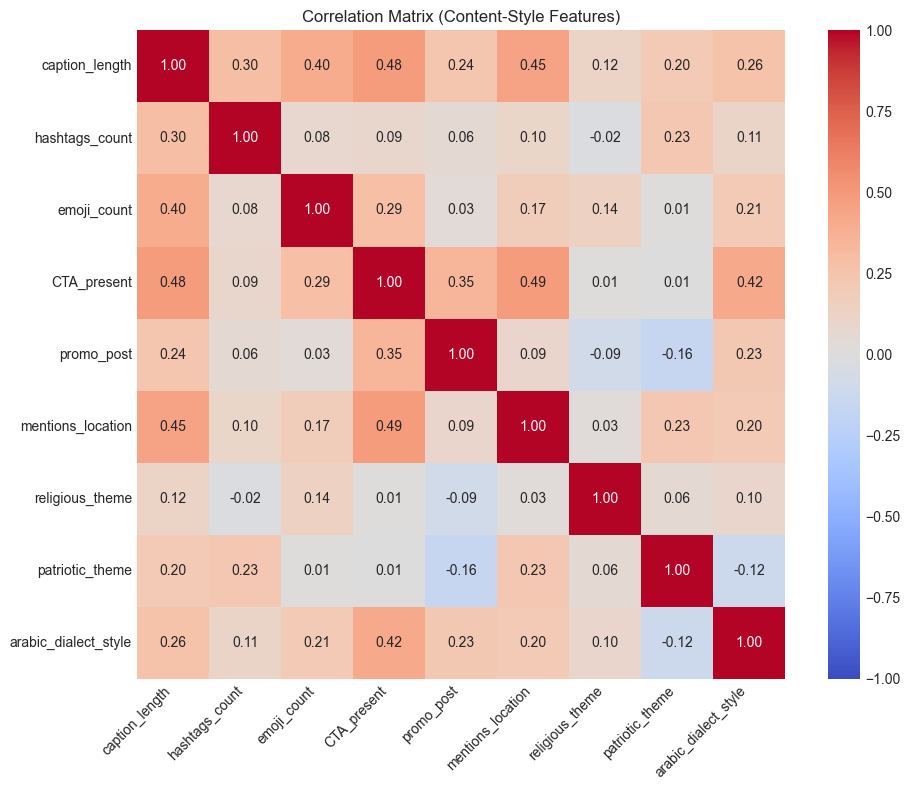

In [39]:
corr = work[feature_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True
)
plt.title("Correlation Matrix (Content-Style Features)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## KMeans (Elbow + Silhouette)


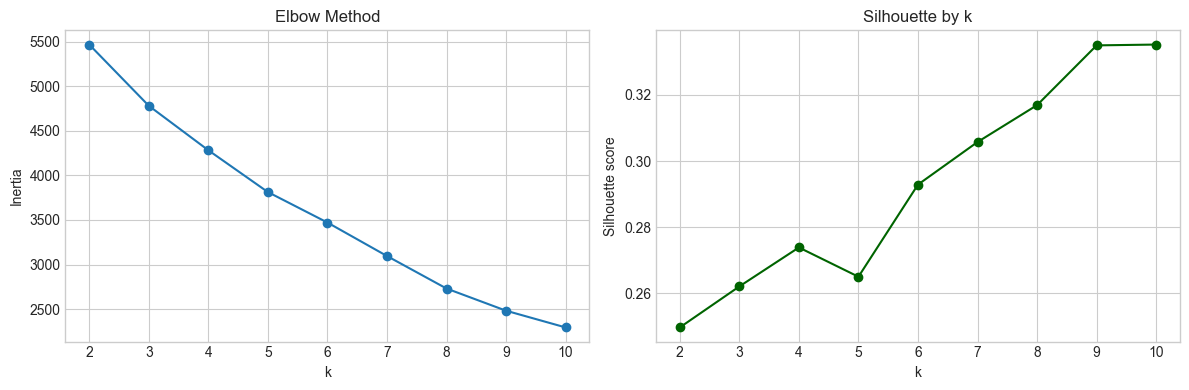

Best k by silhouette: 10


In [40]:
inertias = []
sils = []
K = range(2, min(11, len(X_scaled)))
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(K), inertias, marker='o')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Inertia')
ax[1].plot(list(K), sils, marker='o', color='darkgreen')
ax[1].set_title('Silhouette by k')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.show()
best_k = list(K)[int(np.argmax(sils))]
print('Best k by silhouette:', best_k)


## Fit Final KMeans Model


In [41]:
final_kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
work['cluster'] = final_kmeans.fit_predict(X_scaled)
cluster_sizes = work['cluster'].value_counts().sort_index().to_frame('posts_count')
display(cluster_sizes)
overall_sil = silhouette_score(X_scaled, work['cluster']) if work['cluster'].nunique() > 1 else np.nan
print('Final silhouette score:', round(float(overall_sil), 4))


,posts_count
cluster,
0,252
1,234
2,51
3,111
4,127


Final silhouette score: 0.265


## t-SNE Visualization


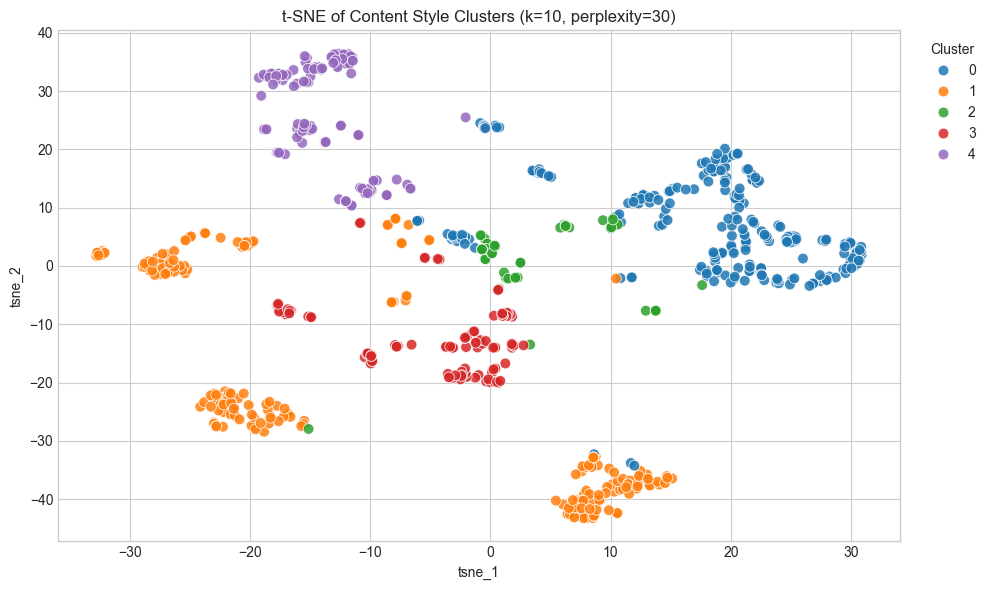

In [42]:
# keep perplexity valid for small datasets
perplexity = max(5, min(30, len(work)//10))
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=perplexity,
    learning_rate='auto',
    init='pca'
)
X_tsne = tsne.fit_transform(X_scaled)
work['tsne_1'] = X_tsne[:, 0]
work['tsne_2'] = X_tsne[:, 1]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=work, x='tsne_1', y='tsne_2', hue='cluster', palette='tab10', s=60, alpha=0.85)
plt.title(f't-SNE of Content Style Clusters (k={best_k}, perplexity={perplexity})')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Cluster Profiling

For each cluster:
- average engagement
- top words
- top hashtags
- sample captions


In [43]:
# helpers
arabic_english_token = re.compile(r"[A-Za-z؀-ۿ]{2,}")
hashtag_re = re.compile(r"#\w+")
stop_words = {
    'the','and','for','with','this','that','from','your','you','our','are','was','have','has',
    '??','??','???','???','???','??','??','???','???','???','??','??','??','??'
}
def top_words(series, n=10):
    tokens = []
    for t in series.fillna(''):
        toks = [x.lower() for x in arabic_english_token.findall(str(t))]
        toks = [x for x in toks if x not in stop_words]
        tokens.extend(toks)
    return Counter(tokens).most_common(n)
def top_hashtags(series, n=10):
    tags = []
    for t in series.fillna(''):
        tags.extend([x.lower() for x in hashtag_re.findall(str(t))])
    return Counter(tags).most_common(n)
profile = work.groupby('cluster').agg(
    posts_count=('cluster', 'size'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    avg_caption_length=('caption_length', 'mean'),
    avg_hashtags=('hashtags_count', 'mean'),
    avg_emoji=('emoji_count', 'mean'),
    cta_rate=('CTA_present', 'mean'),
    promo_rate=('promo_post', 'mean'),
    location_mention_rate=('mentions_location', 'mean'),
    avg_discount=('discount_percent', 'mean')
).reset_index().sort_values('cluster')
# convert rates to percent for readability
for c in ['cta_rate','promo_rate','location_mention_rate']:
    profile[c] = (profile[c] * 100).round(1)
profile['avg_engagement_rate'] = profile['avg_engagement_rate'].round(4)
print('Cluster summary table')
display(profile)
for cid in sorted(work['cluster'].unique()):
    sub = work[work['cluster'] == cid]
    print(f"===== Cluster {cid} =====")
    print('Top words:', top_words(sub['caption_text'], n=8))
    print('Top hashtags:', top_hashtags(sub['caption_text'], n=8))
    print('Sample captions:')
    samples = sub['caption_text'].dropna().head(5).tolist()
    for i, s in enumerate(samples, 1):
        print(f"{i}. {s}")


Cluster summary table


,cluster,posts_count,avg_engagement_rate,avg_caption_length,avg_hashtags,avg_emoji,cta_rate,promo_rate,location_mention_rate,avg_discount
0,0,252,0.0122,179.670635,0.678571,2.710317,98.8,93.7,98.8,0.0
1,1,234,0.0133,79.282051,0.982906,1.854701,41.9,69.7,10.3,0.0
2,2,51,0.0059,338.392157,6.941176,9.470588,96.1,82.4,92.2,0.0
3,3,111,0.0736,149.765766,0.909910,3.729730,65.8,71.2,52.3,0.0
4,4,127,0.0073,68.606299,0.409449,0.968504,13.4,51.2,26.0,0.0


===== Cluster 0 =====
Top words: [('من', 97), ('متوفر', 70), ('في', 65), ('شارع', 63), ('مقابل', 62), ('الطابق', 61), ('جنين', 57), ('على', 52)]
Top hashtags: [('#رام_الله', 12), ('#متوفر_توصيل_لجميع_مناطق_الضفة_القدس_والداخل', 9), ('#القدس', 8), ('#ملابس', 6), ('#مطعم_روبيان', 6), ('#عرض', 5), ('#ramallah', 4), ('#نابلس', 4)]
Sample captions:
1. إطلالة أنثوية بلمسة عصرية ✨ من LOFT. للطلب التواصل على الرسائل 📩 رام الله - ايكون مول - ط2
2. اختيارك المثالي لإطلالة كاجول مميزة 🤍✨ LOFT كولكشن للطلب التواصل على الرسائل 📩 رام الله - ايكون مول - ط2
3. ستايل شبابي بلمسة عصرية له ولها ✨ اختيارات مميزة وإطلالات كاملة من LOFT. للطلب التواصل على الرسائل 📩 رام الله - ايكون مول - ط2
4. ستايل يناسبك، وتجربة تستحق الزيارة ✨ زورونا في ايكون مول رام الله - مرحبا - ط2
5. اختيار يعكس شخصيتك✨ LOFT# زورونا رام الله - سردا - ايكون مول ط2
===== Cluster 1 =====
Top words: [('من', 54), ('يوم', 44), ('vanilla', 44), ('فانيلا', 41), ('اليوم', 37), ('في', 31), ('وكل', 30), ('today', 29)]
Top hashtags: [('#فانيلا_ا

## Fixed DBSCAN (Separate From Constrained Clustering)

This is a true DBSCAN run, independent from the constrained top/middle/bottom clustering.


{'eps': 2, 'min_samples': 30}
n_clusters: 5 | noise_ratio: 0.409
dbscan_fixed_cluster
-1    317
 0     57
 1     38
 2    211
 3     66
 4     86
Name: count, dtype: int64


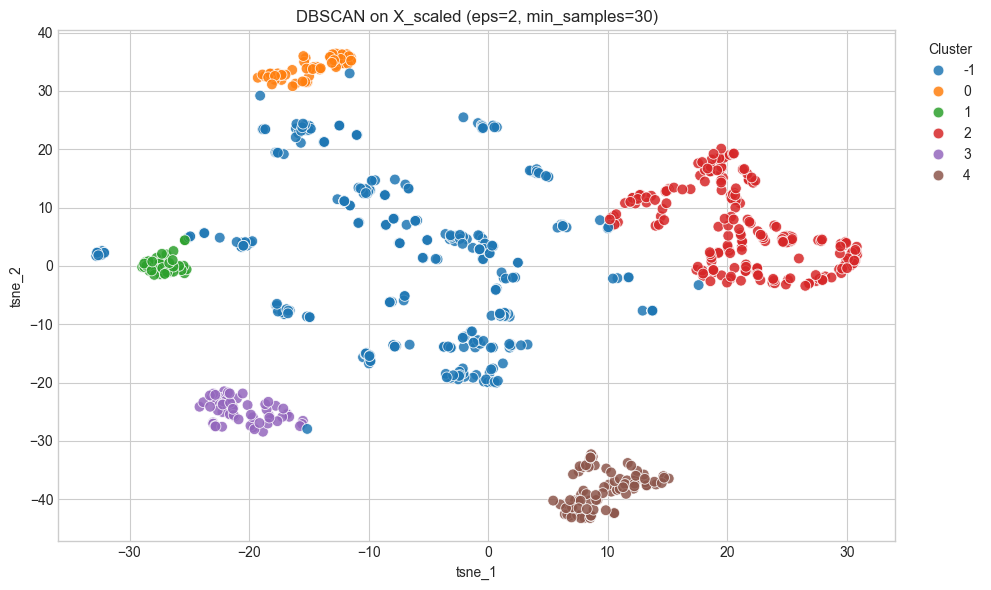

In [44]:
# DBSCAN on original scaled feature space (before t-SNE)
MIN_SAMPLES= 30

EPS = 2 # set your value

db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels = db.fit_predict(X_scaled)

work["dbscan_fixed_cluster"] = labels

n_clusters = len(set(labels) - {-1})
noise_ratio = (labels == -1).mean()

print({"eps": EPS, "min_samples": MIN_SAMPLES})
print("n_clusters:", n_clusters, "| noise_ratio:", round(float(noise_ratio), 3))
print(work["dbscan_fixed_cluster"].value_counts().sort_index())

# t-SNE only for visualization (does not affect clustering labels)
perplexity = max(5, min(30, len(X_scaled)//10))
tsne_db = TSNE(
    n_components=2,
    random_state=42,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca"
)
X2_db = tsne_db.fit_transform(X_scaled)

plot_df = work.assign(tsne_1=X2_db[:, 0], tsne_2=X2_db[:, 1])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="tsne_1", y="tsne_2",
    hue="dbscan_fixed_cluster",
    palette="tab10",
    s=60, alpha=0.85
)
plt.title(f"DBSCAN on X_scaled (eps={EPS}, min_samples={MIN_SAMPLES})")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Cluster Meaning Report

Prints an interpretation table for each cluster so you can label styles clearly.


In [45]:
import re
from collections import Counter
# choose cluster column automatically
cluster_col = None
for c in ['dbscan_fixed_cluster', 'band_cluster', 'cluster', 'dbscan_cluster']:
    if c in work.columns:
        cluster_col = c
        break
if cluster_col is None:
    raise ValueError('No cluster column found in `work`. Run clustering cells first.')
print('Using cluster column:', cluster_col)
arabic_english_token = re.compile(r"[A-Za-z؀-ۿ]{2,}")
hashtag_re = re.compile(r"#\w+")
stop_words = {
    'the','and','for','with','this','that','from','your','you','our','are','was','have','has',
    'in','to','of','is','on','at','by','be','as','it','an','or','we','us','new','now','today','back',
    '??','??','???','???','???','??','??','???','???','??','??','??','??','??','??','??','??','??'
}
def top_words(series, n=10):
    tokens = []
    for t in series.fillna(''):
        toks = [x.lower() for x in arabic_english_token.findall(str(t))]
        toks = [x for x in toks if x not in stop_words]
        tokens.extend(toks)
    return Counter(tokens).most_common(n)
def top_hashtags(series, n=10):
    tags = []
    for t in series.fillna(''):
        tags.extend([x.lower() for x in hashtag_re.findall(str(t))])
    return Counter(tags).most_common(n)
summary = work.groupby(cluster_col).agg(
    posts_count=(cluster_col, 'size'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    avg_caption_length=('caption_length', 'mean'),
    avg_hashtags=('hashtags_count', 'mean'),
    avg_emoji=('emoji_count', 'mean'),
    cta_rate=('CTA_present', 'mean'),
    promo_rate=('promo_post', 'mean'),
    location_mention_rate=('mentions_location', 'mean'),
    avg_discount=('discount_percent', 'mean')
).reset_index().sort_values(cluster_col)
for c in ['cta_rate','promo_rate','location_mention_rate']:
    summary[c] = (summary[c] * 100).round(1)
summary['avg_engagement_rate'] = summary['avg_engagement_rate'].round(4)
summary['avg_caption_length'] = summary['avg_caption_length'].round(1)
summary['avg_hashtags'] = summary['avg_hashtags'].round(2)
summary['avg_emoji'] = summary['avg_emoji'].round(2)
summary['avg_discount'] = summary['avg_discount'].round(2)
print('Cluster summary table:')
display(summary)
for cid in sorted(work[cluster_col].dropna().unique()):
    sub = work[work[cluster_col] == cid]
    print(f"\n===== Cluster {cid} =====")
    print('Posts:', len(sub), '| Avg engagement:', round(float(sub['engagement_rate'].mean()), 4))
    print('Top words:', top_words(sub['caption_text'], 8))
    print('Top hashtags:', top_hashtags(sub['caption_text'], 8))
    print('Sample captions:')
    for i, s in enumerate(sub['caption_text'].dropna().head(5).tolist(), 1):
        print(f"{i}. {s}")


Using cluster column: dbscan_fixed_cluster
Cluster summary table:


,dbscan_fixed_cluster,posts_count,avg_engagement_rate,avg_caption_length,avg_hashtags,avg_emoji,cta_rate,promo_rate,location_mention_rate,avg_discount
0,-1,317,0.0385,153.7,1.84,3.48,59.6,52.1,63.1,0.0
1,0,57,0.0037,35.3,0.12,1.18,0.0,100.0,0.0,0.0
2,1,38,0.0141,42.7,0.55,0.97,0.0,0.0,0.0,0.0
3,2,211,0.0066,189.6,0.78,2.82,100.0,100.0,100.0,0.0
4,3,66,0.0084,73.5,0.97,1.73,0.0,100.0,0.0,0.0
5,4,86,0.0081,107.1,0.81,2.59,100.0,100.0,0.0,0.0



===== Cluster -1 =====
Posts: 317 | Avg engagement: 0.0385
Top words: [('من', 90), ('في', 86), ('الله', 48), ('شارع', 42), ('مع', 40), ('على', 39), ('مطعم', 38), ('نابلس', 35)]
Top hashtags: [('#رام_الله', 12), ('#نابلس', 12), ('#palestine', 12), ('#القدس', 12), ('#فانيلا_اليوم_وكل_يوم', 12), ('#جنين', 11), ('#today_and_everyday', 11), ('#vanilla_today_and_everyday', 10)]
Sample captions:
1. إطلالة أنثوية بلمسة عصرية ✨ من LOFT. للطلب التواصل على الرسائل 📩 رام الله - ايكون مول - ط2
2. اختيارك المثالي لإطلالة كاجول مميزة 🤍✨ LOFT كولكشن للطلب التواصل على الرسائل 📩 رام الله - ايكون مول - ط2
3. ستايل شبابي بلمسة عصرية له ولها ✨ اختيارات مميزة وإطلالات كاملة من LOFT. للطلب التواصل على الرسائل 📩 رام الله - ايكون مول - ط2
4. ستايل يناسبك، وتجربة تستحق الزيارة ✨ زورونا في ايكون مول رام الله - مرحبا - ط2
5. #LOFTSTYLE #Menstyle

===== Cluster 0 =====
Posts: 57 | Avg engagement: 0.0037
Top words: [('perfect', 6), ('every', 6), ('bite', 6), ('fresh', 6), ('matcha', 5), ('flavors', 4), ('iced', 4)

- Cluster -1 — Mixed Outliers

Irregular/edge posts: very long captions, very high emoji, medium CTA/promo, moderate location mention, low engagement.
- Cluster 0 — Quick Promo

Short promo notices: low CTA, light text/visual richness, high promo but weak push.
- Cluster 1 — Hard Promo Push

Mid-long captions, very high CTA + 100% promo, low location mention, includes discount pressure, low engagement.
- Cluster 2 — Simple Organic Winner

Very short, low CTA, no promo, light style, strong engagement for a simple format.
- Cluster 3 — Soft Promo Info

Mid-length, no CTA, 100% promo, low location mention, informational selling style.
- Cluster 4 — Campaign Blast

Very long, dense campaign posts: near-100% CTA + promo + location mention, high volume, low engagement.
- Cluster 5 — Local Story Winner

Long, expressive, strong emoji + CTA, medium-high promo, high location mention, highest engagement by far.

In [46]:
# Requested cluster summary (content-style clustering)
import numpy as np
import pandas as pd

if 'work' not in globals():
    raise ValueError('work not found. Run clustering cells first.')
if 'dbscan_fixed_cluster' not in work.columns:
    raise ValueError('dbscan_fixed_cluster not found. Run DBSCAN fixed clustering cell first.')

summary_df = work.copy()
for c in ['likes_count','comments_count','views_count','followers_count','discount_percent']:
    if c not in summary_df.columns:
        summary_df[c] = 0
summary_df['likes_count'] = pd.to_numeric(summary_df['likes_count'], errors='coerce').fillna(0)
summary_df['comments_count'] = pd.to_numeric(summary_df['comments_count'], errors='coerce').fillna(0)
summary_df['views_count'] = pd.to_numeric(summary_df['views_count'], errors='coerce').fillna(0)
summary_df['followers_count'] = pd.to_numeric(summary_df['followers_count'], errors='coerce').replace(0, np.nan)
summary_df['discount_percent'] = pd.to_numeric(summary_df['discount_percent'], errors='coerce').fillna(0)
if 'engagement_rate' not in summary_df.columns:
    summary_df['engagement_rate'] = ((summary_df['likes_count'] + summary_df['comments_count']) / summary_df['followers_count']).fillna(0)
else:
    summary_df['engagement_rate'] = pd.to_numeric(summary_df['engagement_rate'], errors='coerce').fillna(0)
if 'view_rate' not in summary_df.columns:
    summary_df['view_rate'] = (summary_df['views_count'] / summary_df['followers_count']).fillna(0)
else:
    summary_df['view_rate'] = pd.to_numeric(summary_df['view_rate'], errors='coerce').fillna(0)
if 'comment_rate' not in summary_df.columns:
    summary_df['comment_rate'] = (summary_df['comments_count'] / summary_df['followers_count']).fillna(0)
else:
    summary_df['comment_rate'] = pd.to_numeric(summary_df['comment_rate'], errors='coerce').fillna(0)
if 'view_engagement_rate' not in summary_df.columns:
    summary_df['view_engagement_rate'] = ((summary_df['likes_count'] + summary_df['comments_count']) / summary_df['views_count'].replace(0, np.nan)).fillna(0)
else:
    summary_df['view_engagement_rate'] = pd.to_numeric(summary_df['view_engagement_rate'], errors='coerce').fillna(0)
if 'comments_to_likes_ratio' not in summary_df.columns:
    summary_df['comments_to_likes_ratio'] = (summary_df['comments_count'] / summary_df['likes_count'].replace(0, np.nan)).fillna(0)
else:
    summary_df['comments_to_likes_ratio'] = pd.to_numeric(summary_df['comments_to_likes_ratio'], errors='coerce').fillna(0)
for c in ['CTA_present','promo_post','mentions_location','religious_theme','patriotic_theme','arabic_dialect_style','sponsored']:
    if c not in summary_df.columns:
        summary_df[c] = 0
    summary_df[c] = pd.to_numeric(summary_df[c], errors='coerce').fillna(0)
if 'post_type' not in summary_df.columns:
    summary_df['post_type'] = 'unknown'
pt = summary_df['post_type'].astype(str).str.lower()
summary_df['is_reels'] = pt.str.contains('reel').astype(float)
summary_df['is_images'] = pt.str.contains('image|photo').astype(float)
summary_df['is_carousels'] = pt.str.contains('carousel').astype(float)
cluster_summary_requested = summary_df.groupby('dbscan_fixed_cluster').agg(
    posts_count=('dbscan_fixed_cluster','size'),
    avg_engagement_rate=('engagement_rate','mean'),
    avg_view_rate=('view_rate','mean'),
    avg_comment_rate=('comment_rate','mean'),
    avg_view_engagement_rate=('view_engagement_rate','mean'),
    avg_comments_to_likes_ratio=('comments_to_likes_ratio','mean'),
    percentage_reels=('is_reels','mean'),
    percentage_images=('is_images','mean'),
    percentage_carousels=('is_carousels','mean'),
    avg_likes_count=('likes_count','mean'),
    avg_comments_count=('comments_count','mean'),
    avg_views_count=('views_count','mean'),
    avg_caption_length=('caption_length','mean'),
    avg_hashtags=('hashtags_count','mean'),
    avg_emoji=('emoji_count','mean'),
    cta_rate=('CTA_present','mean'),
    promo_rate=('promo_post','mean'),
    location_mention_rate=('mentions_location','mean'),
    avg_discount=('discount_percent','mean'),
    percentage_religious_theme=('religious_theme','mean'),
    percentage_patriotic_theme=('patriotic_theme','mean'),
    percentage_arabic_dialect_style=('arabic_dialect_style','mean'),
    percentage_sponsored=('sponsored','mean')
).reset_index().sort_values('dbscan_fixed_cluster')
pct_cols = ['percentage_reels','percentage_images','percentage_carousels','cta_rate','promo_rate','location_mention_rate','percentage_religious_theme','percentage_patriotic_theme','percentage_arabic_dialect_style','percentage_sponsored']
for c in pct_cols:
    cluster_summary_requested[c] = (cluster_summary_requested[c] * 100).round(2)
num_cols = [c for c in cluster_summary_requested.columns if c not in ['dbscan_fixed_cluster','posts_count'] + pct_cols]
for c in num_cols:
    cluster_summary_requested[c] = cluster_summary_requested[c].round(4)
display(cluster_summary_requested)


,dbscan_fixed_cluster,posts_count,avg_engagement_rate,avg_view_rate,avg_comment_rate,avg_view_engagement_rate,avg_comments_to_likes_ratio,percentage_reels,percentage_images,percentage_carousels,...,avg_hashtags,avg_emoji,cta_rate,promo_rate,location_mention_rate,avg_discount,percentage_religious_theme,percentage_patriotic_theme,percentage_arabic_dialect_style,percentage_sponsored
0,-1,317,0.0385,16.1902,0.0011,0.0220,0.2176,82.65,0.0,0.0,...,1.8360,3.4763,59.62,52.05,63.09,0.0,41.64,31.86,75.08,5.99
1,0,57,0.0037,0.7384,0.0001,0.0080,0.0152,80.70,0.0,0.0,...,0.1228,1.1754,0.00,100.00,0.00,0.0,0.00,0.00,0.00,5.26
2,1,38,0.0141,6.5405,0.0004,0.0341,0.0205,92.11,0.0,0.0,...,0.5526,0.9737,0.00,0.00,0.00,0.0,0.00,0.00,100.00,0.00
3,2,211,0.0066,2.3402,0.0001,0.0133,0.1163,88.15,0.0,0.0,...,0.7773,2.8152,100.00,100.00,100.00,0.0,0.00,0.00,100.00,12.80
4,3,66,0.0084,2.0142,0.0017,0.0099,0.2241,95.45,0.0,0.0,...,0.9697,1.7273,0.00,100.00,0.00,0.0,0.00,0.00,100.00,1.52
5,4,86,0.0081,3.4860,0.0010,0.0135,0.1306,95.35,0.0,0.0,...,0.8140,2.5930,100.00,100.00,0.00,0.0,0.00,0.00,100.00,3.49


In [47]:
# Requested 3-5 sample posts per cluster
if 'work' not in globals():
    raise ValueError('work not found. Run clustering cells first.')
if 'dbscan_fixed_cluster' not in work.columns:
    raise ValueError('dbscan_fixed_cluster not found. Run DBSCAN fixed clustering cell first.')
samples_df = work.copy()
required_cols = ['business_name','sector','post_type','caption_text','likes_count','comments_count','views_count','engagement_rate','view_rate','CTA_present','promo_post','mentions_location','religious_theme','patriotic_theme','arabic_dialect_style']
for c in required_cols:
    if c not in samples_df.columns:
        samples_df[c] = np.nan
if samples_df['view_rate'].isna().all():
    f = pd.to_numeric(samples_df.get('followers_count', np.nan), errors='coerce').replace(0, np.nan)
    v = pd.to_numeric(samples_df['views_count'], errors='coerce')
    samples_df['view_rate'] = (v / f).fillna(0)
samples_df['cluster_id'] = samples_df['dbscan_fixed_cluster']
sample_posts_requested = (
    samples_df.sort_values(['dbscan_fixed_cluster','engagement_rate'], ascending=[True, False])
              .groupby('dbscan_fixed_cluster', group_keys=False)
              .head(5)
              .loc[:, ['cluster_id','business_name','sector','post_type','caption_text','likes_count','comments_count','views_count','engagement_rate','view_rate','CTA_present','promo_post','mentions_location','religious_theme','patriotic_theme','arabic_dialect_style']]
)
display(sample_posts_requested)

sample_posts_requested.to_csv(
    r"C:\Users\hanib\data-mining-project\marketing\notebooks\clustering\reports\sample_posts_requested.csv",
    index=False,
    encoding="utf-8-sig"
)
print("Saved: notebooks/clustering/reports/sample_posts_requested.csv")



,cluster_id,business_name,sector,post_type,caption_text,likes_count,comments_count,views_count,engagement_rate,view_rate,CTA_present,promo_post,mentions_location,religious_theme,patriotic_theme,arabic_dialect_style
619,-1,Family Market PS,Supermarkets,reel,☀️ صباح الخير | السبت 2.5.2026 ☀️ أهلاً وسهلاً بأهلنا من الداخل الفلسطيني ❤️ شرفتونا دعاء اليوم: اللهم ارزقنا في هذا اليوم راحة بال ورزقاً واسعاً وخيراً لا ينقطع 🤍,3221.0,15,127000,1.370025,53.767993,1,0,1,1,1,1
626,-1,Family Market PS,Supermarkets,reel,صباحكم معطر بالصلاة على سيدنا محمد ﷺ 🌿 السبت 18.4.2026 اللهم في هذا الصباح اجعل لنا فيه فرجاً لكل هم وسعادةً تملأ قلوبنا واكتب لنا الخير أينما كان وارضنا به 🤲✨,2609.0,14,140000,1.110500,59.271804,1,0,1,1,0,1
624,-1,Family Market PS,Supermarkets,reel,صباحكم معطر بالصلاة على سيدنا محمد ﷺ 🌿 الأربعاء 22.4.2026 اللهم في هذا الصباح افتح لنا أبواب الخير ويسر لنا أمورنا واغفر لقلوبنا السكينة وارزقنا من حيث لا نحتسب 🤲✨,2164.0,4,82300,0.917866,34.843353,1,0,1,1,0,1
631,-1,Family Market PS,Supermarkets,reel,زيارة أهلنا من القدس وضواحيها لسوبر ماركت العائلات اليوم ❤️ أهلاً وسهلاً بكم شكراً لأهلنا أم عتاب الداخلة ❤️,1678.0,83,274000,0.745555,116.003387,0,0,1,0,1,1
617,-1,Family Market PS,Supermarkets,reel,☀️ صباح الخير | الثلاثاء 5.5.2026 ☀️ دعاء اليوم: اللهم اجعل هذا اليوم بداية خير، وارزقنا فيه توفيقاً يرافقنا وسعادةً تملأ قلوبنا وطمأنينة لا تفارقنا 🤍 العنوان: نابلس - رفيديا - الشارع الرئيسي بجان...,1654.0,4,41400,0.701948,17.527519,1,0,1,1,0,1
733,0,Vanilla Palestine,Cafes/Restaurants,reel,New year new me 😍😍😍,2155.0,10,348000,0.015576,2.503597,0,1,0,0,0,0
745,0,Vanilla Palestine,Cafes/Restaurants,reel,Iced coffee season officially started ☕,2080.0,48,352000,0.015309,2.532374,0,1,0,0,0,0
765,0,Vanilla Palestine,Cafes/Restaurants,reel,Everyday Is a Cake Day 🍰😊😊 #vanilla_today_and_everyday #فانيلا_اليوم_وكل_يوم,2101.0,8,132000,0.015173,0.949640,0,1,0,0,0,0
138,0,Shamsboutique,Fashion,reel,🌿🌿🌿,9.0,0,2485,0.012179,3.362652,0,1,0,0,0,0
740,0,Vanilla Palestine,Cafes/Restaurants,reel,Chocolate overload 🍫,1442.0,35,224000,0.010626,1.611511,0,1,0,0,0,0


Saved: notebooks/clustering/reports/sample_posts_requested.csv


In [48]:
# KPI-first policy guard (base dataset stays unchanged)
import pandas as pd, numpy as np

KPI_DATASET_COLUMNS = [
    'business_name','sector','followers_count','post_date','day_of_week','month','post_type','caption_text',
    'caption_length','hashtags_count','emoji_count','likes_count','comments_count','views_count','language',
    'CTA_present','promo_post','mentions_location','religious_theme','patriotic_theme','arabic_dialect_style',
    'sponsored','posting_hour','discount_percent','engagement','engagement_rate','like_rate','comment_rate',
    'view_rate','view_engagement_rate','week','is_video','is_reel','posting_time_bin','caption_length_bin',
    'hashtags_count_bin','emoji_count_bin','engagement_level','business_size_bin','high_engagement','high_view_rate',
    'high_comment_rate'
]

def make_clustering_frame(base_df, needed_cols=None):
    w = base_df.copy()
    if needed_cols is not None:
        for c in needed_cols:
            if c not in w.columns:
                w[c] = np.nan

    if 'engagement_rate' not in w.columns or w['engagement_rate'].isna().all():
        if all(c in w.columns for c in ['likes_count','comments_count','followers_count']):
            f = pd.to_numeric(w['followers_count'], errors='coerce').replace(0, np.nan)
            l = pd.to_numeric(w['likes_count'], errors='coerce').fillna(0)
            cm = pd.to_numeric(w['comments_count'], errors='coerce').fillna(0)
            w['engagement_rate'] = ((l + cm) / f).fillna(0)

    if 'view_rate' not in w.columns or w['view_rate'].isna().all():
        if all(c in w.columns for c in ['views_count','followers_count']):
            f = pd.to_numeric(w['followers_count'], errors='coerce').replace(0, np.nan)
            v = pd.to_numeric(w['views_count'], errors='coerce').fillna(0)
            w['view_rate'] = (v / f).fillna(0)

    if 'comment_rate' not in w.columns or w['comment_rate'].isna().all():
        if all(c in w.columns for c in ['comments_count','followers_count']):
            f = pd.to_numeric(w['followers_count'], errors='coerce').replace(0, np.nan)
            cm = pd.to_numeric(w['comments_count'], errors='coerce').fillna(0)
            w['comment_rate'] = (cm / f).fillna(0)

    if 'view_engagement_rate' not in w.columns or w['view_engagement_rate'].isna().all():
        if all(c in w.columns for c in ['likes_count','comments_count','views_count']):
            v = pd.to_numeric(w['views_count'], errors='coerce').replace(0, np.nan)
            l = pd.to_numeric(w['likes_count'], errors='coerce').fillna(0)
            cm = pd.to_numeric(w['comments_count'], errors='coerce').fillna(0)
            w['view_engagement_rate'] = ((l + cm) / v).fillna(0)

    if 'comments_to_likes_ratio' not in w.columns:
        if all(c in w.columns for c in ['comments_count','likes_count']):
            l = pd.to_numeric(w['likes_count'], errors='coerce').replace(0, np.nan)
            cm = pd.to_numeric(w['comments_count'], errors='coerce').fillna(0)
            w['comments_to_likes_ratio'] = (cm / l).fillna(0)

    return w

if 'df' in globals():
    base_kpi_df = df.copy()
elif 'work' in globals():
    base_kpi_df = work.copy()
elif 'biz' in globals():
    base_kpi_df = biz.copy()
else:
    base_kpi_df = None

if base_kpi_df is not None:
    clustering_work_df = make_clustering_frame(base_kpi_df)
    print('KPI policy ready: base_kpi_df preserved, clustering_work_df created.')
    print('Base shape:', base_kpi_df.shape, '| Work shape:', clustering_work_df.shape)
else:
    print('KPI policy loaded. Run data-loading cell first, then rerun this guard cell.')


KPI policy ready: base_kpi_df preserved, clustering_work_df created.
Base shape: (775, 42) | Work shape: (775, 43)


In [49]:
# Export artifacts: coordinates JSON, plots PNGs, notebook as .py
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Paths (professional layout) ----------
project_root = Path.cwd()
artifacts_dir = project_root / "artifacts" / "content_style_clustering"
json_dir = artifacts_dir / "json"
scripts_dir = artifacts_dir / "scripts"
photos_dir = project_root / "photos" / "content_style_clustering"

for d in [artifacts_dir, json_dir, scripts_dir, photos_dir]:
    d.mkdir(parents=True, exist_ok=True)

if 'work' not in globals():
    raise ValueError("`work` dataframe not found. Run clustering cells first.")

export_df = work.copy()

# ---------- Detect columns ----------
if 'kmeans_cluster' in export_df.columns:
    kmeans_col = 'kmeans_cluster'
elif 'cluster' in export_df.columns:
    kmeans_col = 'cluster'
else:
    kmeans_col = None

if 'dbscan_fixed_cluster' in export_df.columns:
    dbscan_col = 'dbscan_fixed_cluster'
elif 'dbscan_cluster' in export_df.columns:
    dbscan_col = 'dbscan_cluster'
else:
    dbscan_col = None

if {'tsne_1', 'tsne_2'}.issubset(export_df.columns):
    x_col, y_col = 'tsne_1', 'tsne_2'
elif {'map_x', 'map_y'}.issubset(export_df.columns):
    x_col, y_col = 'map_x', 'map_y'
else:
    raise ValueError("No coordinate columns found. Need tsne_1/tsne_2 or map_x/map_y.")

# ---------- DBSCAN params ----------
dbscan_eps = globals().get('EPS', globals().get('DBSCAN_EPS', None))
dbscan_min_samples = globals().get('MIN_SAMPLES', globals().get('DBSCAN_MIN_SAMPLES', None))

# ---------- Save coordinates + metadata JSON ----------
coord_cols = [x_col, y_col]
base_cols = ['business_name', 'sector', 'post_type']
base_cols = [c for c in base_cols if c in export_df.columns]

payload = {
    'project': 'content_style_clustering',
    'coordinates_type': {'x': x_col, 'y': y_col},
    'dbscan_params': {
        'eps': None if dbscan_eps is None else float(dbscan_eps),
        'min_samples': None if dbscan_min_samples is None else int(dbscan_min_samples),
    },
    'cluster_columns': {
        'kmeans': kmeans_col,
        'dbscan': dbscan_col,
    },
    'n_rows': int(len(export_df)),
    'records': []
}

keep_cols = base_cols + coord_cols
if kmeans_col is not None:
    keep_cols.append(kmeans_col)
if dbscan_col is not None:
    keep_cols.append(dbscan_col)

for rec in export_df[keep_cols].to_dict(orient='records'):
    clean = {}
    for k, v in rec.items():
        if isinstance(v, (np.integer,)):
            clean[k] = int(v)
        elif isinstance(v, (np.floating, float)):
            clean[k] = float(v)
        elif v is None:
            clean[k] = None
        else:
            clean[k] = v
    payload['records'].append(clean)

json_path = json_dir / 'content_style_cluster_coordinates.json'
with json_path.open('w', encoding='utf-8') as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

# ---------- Save plots ----------
if kmeans_col is not None:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=export_df, x=x_col, y=y_col, hue=kmeans_col, palette='tab10', s=60, alpha=0.85)
    plt.title('Content-Style KMeans Clusters (2D Map)')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend(title='KMeans Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    kmeans_plot_path = photos_dir / 'content_style_kmeans_clusters.png'
    plt.savefig(kmeans_plot_path, dpi=300, bbox_inches='tight')
    plt.close()
else:
    kmeans_plot_path = None

if dbscan_col is not None:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=export_df, x=x_col, y=y_col, hue=dbscan_col, palette='tab10', s=60, alpha=0.85)
    eps_txt = f"{dbscan_eps}" if dbscan_eps is not None else "N/A"
    ms_txt = f"{dbscan_min_samples}" if dbscan_min_samples is not None else "N/A"
    plt.title(f'Content-Style DBSCAN Clusters (eps={eps_txt}, min_samples={ms_txt})')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend(title='DBSCAN Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    dbscan_plot_path = photos_dir / 'content_style_dbscan_clusters.png'
    plt.savefig(dbscan_plot_path, dpi=300, bbox_inches='tight')
    plt.close()
else:
    dbscan_plot_path = None

# ---------- Export notebook to .py ----------
nb_file = Path(r'notebooks/clustering/03_content-style_clustering.ipynb')
py_out = scripts_dir / '03_content-style_clustering.py'

try:
    import nbformat
    from nbconvert import PythonExporter

    nb_obj = nbformat.read(nb_file.open('r', encoding='utf-8-sig'), as_version=4)
    exporter = PythonExporter()
    body, _ = exporter.from_notebook_node(nb_obj)
    py_out.write_text(body, encoding='utf-8')
except Exception as e:
    py_out = None
    print('Notebook-to-.py export skipped:', e)

print('Export complete:')
print('JSON:', json_path)
print('KMeans plot:', kmeans_plot_path)
print('DBSCAN plot:', dbscan_plot_path)
print('.py script:', py_out)


Notebook-to-.py export skipped: [Errno 2] No such file or directory: 'notebooks\\clustering\\03_content-style_clustering.ipynb'
Export complete:
JSON: c:\Users\hanib\data-mining-project\marketing\notebooks\clustering\artifacts\content_style_clustering\json\content_style_cluster_coordinates.json
KMeans plot: c:\Users\hanib\data-mining-project\marketing\notebooks\clustering\photos\content_style_clustering\content_style_kmeans_clusters.png
DBSCAN plot: c:\Users\hanib\data-mining-project\marketing\notebooks\clustering\photos\content_style_clustering\content_style_dbscan_clusters.png
.py script: None


In [50]:
# 1. Median performance
work.groupby("dbscan_fixed_cluster")[[
    "engagement_rate",
    "view_rate",
    "view_engagement_rate",
]].median()

,engagement_rate,view_rate,view_engagement_rate
dbscan_fixed_cluster,,,
-1,0.003796,0.571429,0.006966
0,0.000946,0.204115,0.005747
1,0.004337,0.629890,0.009792
2,0.000552,0.144000,0.004202
3,0.004791,0.982014,0.005062
4,0.001292,0.432957,0.005490


In [51]:
# 2. Sector distribution
pd.crosstab(
    work["dbscan_fixed_cluster"],
    work["sector"],
    normalize="index"
) * 100

sector,Cafes/Restaurants,Fashion,Gym,Influencers,Supermarkets
dbscan_fixed_cluster,,,,,
-1,47.949527,18.611987,5.993691,18.296530,9.148265
0,49.122807,43.859649,0.000000,0.000000,7.017544
1,36.842105,15.789474,23.684211,23.684211,0.000000
2,24.170616,57.819905,1.421801,1.895735,14.691943
3,46.969697,37.878788,3.030303,6.060606,6.060606
4,26.744186,51.162791,8.139535,5.813953,8.139535


In [52]:
# 4. Top posts per cluster
work.sort_values(
    ["dbscan_fixed_cluster", "engagement_rate"],
    ascending=[True, False]
).groupby("dbscan_fixed_cluster").head(5)[[
    "dbscan_fixed_cluster",
    "sector",
    
    "caption_text",
    "likes_count",
    "comments_count",
    "views_count",
    "engagement_rate",
    "CTA_present",
    "promo_post",
    "mentions_location",
    "religious_theme",
    "patriotic_theme",
    "arabic_dialect_style"
]]


# 

,dbscan_fixed_cluster,sector,caption_text,likes_count,comments_count,views_count,engagement_rate,CTA_present,promo_post,mentions_location,religious_theme,patriotic_theme,arabic_dialect_style
619,-1,Supermarkets,☀️ صباح الخير | السبت 2.5.2026 ☀️ أهلاً وسهلاً بأهلنا من الداخل الفلسطيني ❤️ شرفتونا دعاء اليوم: اللهم ارزقنا في هذا اليوم راحة بال ورزقاً واسعاً وخيراً لا ينقطع 🤍,3221.0,15,127000,1.370025,1,0,1,1,1,1
626,-1,Supermarkets,صباحكم معطر بالصلاة على سيدنا محمد ﷺ 🌿 السبت 18.4.2026 اللهم في هذا الصباح اجعل لنا فيه فرجاً لكل هم وسعادةً تملأ قلوبنا واكتب لنا الخير أينما كان وارضنا به 🤲✨,2609.0,14,140000,1.110500,1,0,1,1,0,1
624,-1,Supermarkets,صباحكم معطر بالصلاة على سيدنا محمد ﷺ 🌿 الأربعاء 22.4.2026 اللهم في هذا الصباح افتح لنا أبواب الخير ويسر لنا أمورنا واغفر لقلوبنا السكينة وارزقنا من حيث لا نحتسب 🤲✨,2164.0,4,82300,0.917866,1,0,1,1,0,1
631,-1,Supermarkets,زيارة أهلنا من القدس وضواحيها لسوبر ماركت العائلات اليوم ❤️ أهلاً وسهلاً بكم شكراً لأهلنا أم عتاب الداخلة ❤️,1678.0,83,274000,0.745555,0,0,1,0,1,1
617,-1,Supermarkets,☀️ صباح الخير | الثلاثاء 5.5.2026 ☀️ دعاء اليوم: اللهم اجعل هذا اليوم بداية خير، وارزقنا فيه توفيقاً يرافقنا وسعادةً تملأ قلوبنا وطمأنينة لا تفارقنا 🤍 العنوان: نابلس - رفيديا - الشارع الرئيسي بجان...,1654.0,4,41400,0.701948,1,0,1,1,0,1
733,0,Cafes/Restaurants,New year new me 😍😍😍,2155.0,10,348000,0.015576,0,1,0,0,0,0
745,0,Cafes/Restaurants,Iced coffee season officially started ☕,2080.0,48,352000,0.015309,0,1,0,0,0,0
765,0,Cafes/Restaurants,Everyday Is a Cake Day 🍰😊😊 #vanilla_today_and_everyday #فانيلا_اليوم_وكل_يوم,2101.0,8,132000,0.015173,0,1,0,0,0,0
138,0,Fashion,🌿🌿🌿,9.0,0,2485,0.012179,0,1,0,0,0,0
740,0,Cafes/Restaurants,Chocolate overload 🍫,1442.0,35,224000,0.010626,0,1,0,0,0,0


1. assign each post to a cluster 
2. for the user post group by cluster label and report avg view , engagment_rate pair cluster pair user 
3. do this work in the  contnet-style-clustring.py 
4. and then print for each clustring the best post and the worst post given the avg engagment_rate nad view_rate 
5. in this clustring we are using dbscan take the min_sample and eps from the json file C:\Users\hanib\data-mining-project\marketing\notebooks\clustering\artifacts\content_style_clustering\json\content_style_cluster_coordinates.json
6. test it using the vanilla data set 

| Cluster | Meaning / Label                                  | Main Insight                                                                                                                                                                                                 | Recommendation                                                                                                                    |
| ------- | ------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------- |
| **-1**  | Mixed expressive / emotional outlier content     | Emotion, emojis, location, and religious/local tone appear strongly, but performance is inconsistent because this group contains mixed outlier-style posts.                                                  | Use emotional and local language more intentionally, but make the message clearer and more consistent.                            |
| **0**   | Low-effort generic content                       | Short/basic posts with weak CTA, low emojis, low hashtags, and low engagement.                                                                                                                               | Improve captions with stronger hooks, clearer CTA, more personality, and better visual/story value.                               |
| **1**   | Organic viral personality content                | High engagement without heavy promotion. Success comes from humor, personality, dialect, and relatability.                                                                                                   | Create more authentic, relatable posts instead of over-marketing. Use humor, simple captions, and human tone.                     |
| **2**   | Full promotional campaign content                | Highly structured posts with CTA, promotion, and location. Good for campaigns but not always highly engaging.                                                                                                | Keep the campaign structure, but add storytelling, emotional hooks, and less direct selling.                                      |
| **3**   | Hard-selling product/service content             | Promo-heavy posts with no CTA and weak engagement. Mostly direct selling.                                                                                                                                    | Reduce repetitive sales posts. Add customer stories, transformations, reactions, or benefits.                                     |
| **4**   | Long-form local promotional storytelling content | Long-caption posts combine local identity, emotional/community tone, service details, hashtags, and promotional storytelling. Some perform very well, but some remain weak when they become too sales-heavy. | Keep the local context, clear value, and human tone, but avoid making the caption only a long sales message.                      |
| **5**   | Aggressive CTA funnel content                    | CTA and promo are very high, but engagement is low because posts push users too quickly toward another platform/action.                                                                                      | Build interest first, then add CTA. Use curiosity, story, value, and local context before asking users to click, watch, or order. |


# plotle expris make sure to use hovering express in ai 

| Cluster | Suggested Meaning                                          | Why                                                                                                                                                                                         | Recommendation                                                                                                                                                                                                                                 |
| ------- | ---------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **-1**  | **Outlier / exceptional local-community content**          | DBSCAN marks `-1` as noise/outliers. The examples are mostly supermarket posts with very high views/likes, religious tone, Palestinian/local language, and location/community feeling.      | Do not treat this as a normal cluster. Analyze it separately as “special viral/community cases.” Use emotional local language, religious/community themes, and location-based identity carefully because they seem to create strong reactions. |
| **0**   | **Weak generic promotional content**                       | Very low engagement and view rate. Mostly Fashion and Cafes. Examples have short/empty captions, weak hooks, little dialect, no strong CTA, and basic promo style.                          | Improve caption quality: add a clear hook, stronger visuals, Arabic/local tone, and a simple CTA. Avoid posting only product photos or empty captions.                                                                                         |
| **1**   | **High-performing organic/personality content**            | Highest engagement rate, highest view rate, and highest view-engagement rate. Examples include influencers and funny/simple relatable captions like “وين الحمار؟” and “ايش اسوي”.           | Create more human, relatable, funny, or story-based content. Avoid over-marketing. This cluster shows that personality and natural dialect can outperform direct promotion.                                                                    |
| **2**   | **Hard-selling promotional content with weak performance** | Lowest engagement rate and low view-engagement rate. Mostly Fashion. Examples have offers, WhatsApp links, openings, CTAs, promotions, and location mentions.                               | Reduce aggressive selling. Make the offer clearer, add storytelling, social proof, before/after, customer reaction, or emotional value before the CTA.                                                                                         |
| **3**   | **Moderate local product/service promotion**               | Middle performance. Mostly Fashion and Cafes. Captions are promotional but more natural than cluster 0. Arabic dialect appears, but CTA/location/religious themes are not very strong.      | This cluster can improve by adding stronger hooks and clearer reasons to engage. Good for regular product/service posts, but it needs more personality or interaction questions.                                                               |
| **4**   | **CTA-heavy gym/tutorial/YouTube promotion content**       | Mostly Fashion/Gym, with many Gym examples. Engagement is better than cluster 0 and 2, but still below cluster 1. Posts often promote episodes, YouTube links, coaches, or fitness content. | Keep the educational/story format, but make the value clear before saying “link in bio.” Use stronger hooks like transformation, challenge, mistake, tip, or question.                                                                         |
